## Binning

In [50]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score

In [16]:
df = pd.read_csv('train.csv')[['Age' , 'Fare' , 'SibSp' ,  'Parch' , 'Survived']]

In [17]:
df.dropna(inplace=True)

In [18]:
df.shape

(714, 5)

In [19]:
df.head()

,Age,Fare,SibSp,Parch,Survived
0,22.0,7.2500,1,0,0
1,38.0,71.2833,1,0,1
2,26.0,7.9250,0,0,1
3,35.0,53.1000,1,0,1
4,35.0,8.0500,0,0,0


In [20]:
df['Family'] = df['SibSp'] + df['Parch']
df.head()

,Age,Fare,SibSp,Parch,Survived,Family
0,22.0,7.2500,1,0,0,1
1,38.0,71.2833,1,0,1,1
2,26.0,7.9250,0,0,1,0
3,35.0,53.1000,1,0,1,1
4,35.0,8.0500,0,0,0,0


In [21]:
df.drop(columns=['SibSp' , 'Parch'])

,Age,Fare,Survived,Family
0,22.0,7.2500,0,1
1,38.0,71.2833,1,1
2,26.0,7.9250,1,0
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0
...,...,...,...,...
885,39.0,29.1250,0,5
886,27.0,13.0000,0,0
887,19.0,30.0000,1,0
889,26.0,30.0000,1,0


In [22]:
X = df.drop(columns=['Survived'])

y = df['Survived']

In [23]:
X_train , X_test , y_train , y_test = train_test_split(X , y , random_state=42 , test_size=0.2)

In [24]:
X_train.head()

,Age,Fare,SibSp,Parch,Family
328,31.0,20.5250,1,1,2
73,26.0,14.4542,1,0,1
253,30.0,16.1000,1,0,1
719,33.0,7.7750,0,0,0
666,25.0,13.0000,0,0,0


In [25]:
# Without Binarization 

clf = DecisionTreeClassifier()
clf.fit(X_train , y_train)

y_pred = clf.predict(X_test)

accuracy_score(y_test , y_pred)

0.6083916083916084

In [48]:
np.mean(cross_val_score(DecisionTreeClassifier() , X , y , cv=10 , scoring='accuracy'))

np.float64(0.6471048513302036)

In [27]:
# Applying Binarization

from sklearn.preprocessing import Binarizer
from sklearn.preprocessing import KBinsDiscretizer

In [28]:
k_bin_age = KBinsDiscretizer(n_bins=15 , strategy='quantile' , encode='ordinal')
k_bin_fare = KBinsDiscretizer(n_bins=15 , strategy='quantile' , encode='ordinal')

In [29]:
trf = ColumnTransformer([
    ('first' , k_bin_age , [0]),
    ('second' , k_bin_fare , [1])
])

In [30]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

C:\Users\rishi\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\rishi\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [33]:
trf.named_transformers_['first'].n_bins_

array([15])

In [35]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [32]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1],
})

In [38]:
output['age_labels'] = pd.cut(x=X_train['Age'] , 
                              bins=trf.named_transformers_['first'].bin_edges_[0].tolist())

output['fare_labels'] = pd.cut(x=X_train['Fare'] , 
                              bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [40]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
614,35.0,10.0,8.05,3.0,"(32.0, 35.0]","(7.896, 8.158]"
545,64.0,14.0,26.00,9.0,"(54.0, 80.0]","(18.75, 26.0]"
462,47.0,13.0,38.50,11.0,"(42.0, 47.0]","(31.275, 51.479]"
131,20.0,3.0,7.05,0.0,"(19.0, 21.0]","(0.0, 7.25]"
403,28.0,7.0,15.85,7.0,"(25.0, 28.0]","(14.454, 18.75]"


In [44]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf , y_train)
y_pred2 = clf.predict(X_test_trf)

In [46]:
accuracy_score(y_test , y_pred2)

0.6363636363636364

In [49]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier() , X_trf , y , cv = 10 , scoring='accuracy'))

C:\Users\rishi\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\rishi\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


np.float64(0.6723004694835681)

In [52]:
## fn 

def discretize(bins , strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins , encode = 'ordinal' , strategy = strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins , encode = 'ordinal' , strategy = strategy)

    trf = ColumnTransformer([
        ('first' , kbin_age , [0]),
        ('second' , kbin_fare , [1])
    ])

    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier() , X_trf , y , cv = 10 , scoring='accuracy')))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()

C:\Users\rishi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\rishi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


0.6556142410015648


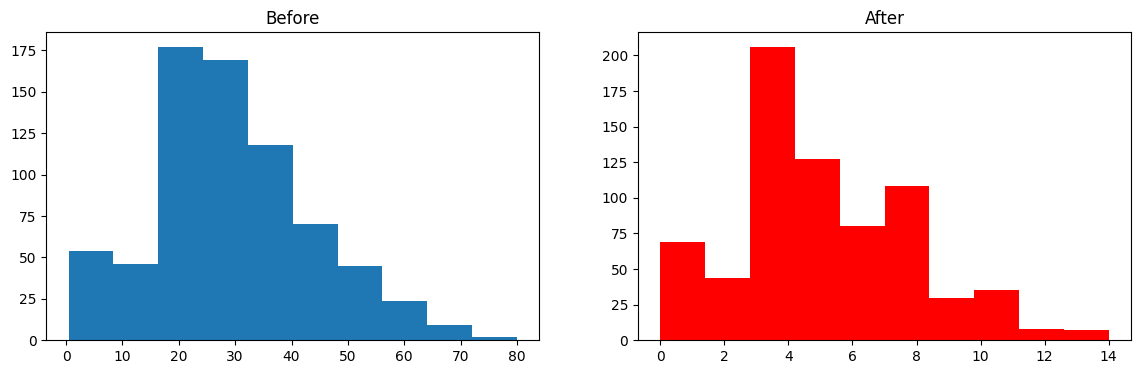

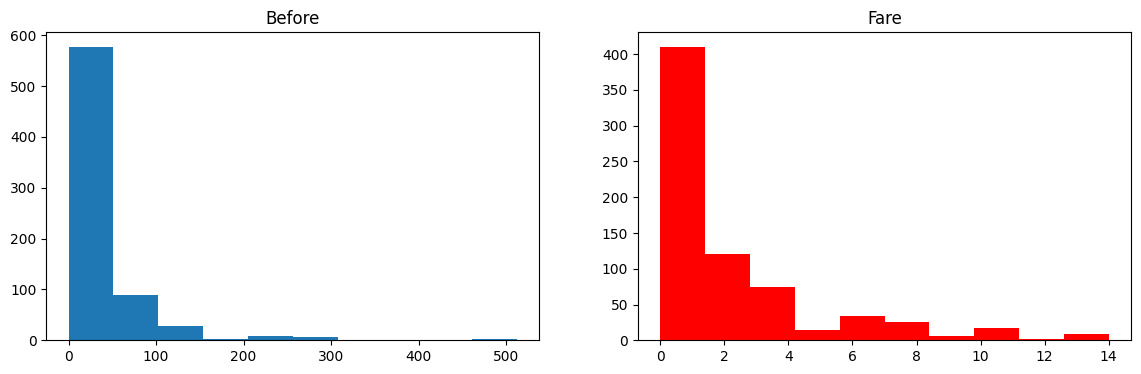

In [54]:
discretize(15 , 'kmeans')